In [1]:
#Cell 1

import os
import shutil
import zipfile
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive

warnings.filterwarnings('ignore')
print("Imports successful.")


Imports successful.


In [2]:
#Cell 2

GDRIVE_ZIP_PATH = '/content/drive/MyDrive/AD_Dataset_compressed.zip'
LOCAL_ZIP_PATH = '/content/Data.zip'
LOCAL_UNZIP_DIR = '/content/Data'
DATA_DIR = '/content/Data/AD Datasets/Data'

IMG_SIZE = (224, 224)
BATCH_SIZE = 128
NUM_CLASSES = 4
EPOCHS = 50
LEARNING_RATE = 1e-4
SEED = 42
BEST_MODEL_SAVE_PATH = 'resnet50_best_model.keras'
AUTOTUNE = tf.data.AUTOTUNE

print("Configuration parameters set.")


Configuration parameters set.


In [3]:
# Cell 3: Mount Google Drive & Extract Dataset

drive.mount('/content/drive', force_remount=True)

if not os.path.exists(GDRIVE_ZIP_PATH):
    raise FileNotFoundError(f"Zip file not found at {GDRIVE_ZIP_PATH}")

shutil.copyfile(GDRIVE_ZIP_PATH, LOCAL_ZIP_PATH)

if os.path.exists(LOCAL_UNZIP_DIR):
    shutil.rmtree(LOCAL_UNZIP_DIR)
os.makedirs(LOCAL_UNZIP_DIR)

with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as z:
    z.extractall(LOCAL_UNZIP_DIR)

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Expected data directory not found at {DATA_DIR}")

print("Dataset successfully extracted.")


Mounted at /content/drive
Dataset successfully extracted.


In [4]:
#Cell 4:  Load Dataset & Split (80/10/10)


full_dataset = image_dataset_from_directory(
    DATA_DIR,
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = full_dataset.class_names
print("Classes:", class_names)

total_batches = tf.data.experimental.cardinality(full_dataset).numpy()
train_batches = int(total_batches * 0.8)
val_batches = int(total_batches * 0.1)
test_batches = total_batches - train_batches - val_batches

if val_batches == 0 and total_batches > train_batches:
    val_batches = 1
if test_batches == 0 and total_batches > train_batches + val_batches:
    test_batches = 1
train_batches = total_batches - val_batches - test_batches

train_dataset = full_dataset.take(train_batches)
val_and_test = full_dataset.skip(train_batches)
val_dataset = val_and_test.take(val_batches)
test_dataset = val_and_test.skip(val_batches)

print(f"Total batches: {total_batches}; train: {train_batches}; val: {val_batches}; test: {test_batches}")


Found 86437 files belonging to 4 classes.
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Total batches: 676; train: 540; val: 67; test: 69


In [8]:
# Cell 5: Class Weights, Caching, and Augmentation


train_label_list = []
for _, lbl in train_dataset:
    train_label_list.extend(lbl.numpy())
train_label_array = np.array(train_label_list)

unique_classes = np.unique(train_label_array)
weights = compute_class_weight('balanced', classes=unique_classes, y=train_label_array)
class_weight_dict = {int(c): float(w) for c, w in zip(unique_classes, weights)}
print("Class weights:", class_weight_dict)

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.15),
])

print("Augmentation and caching configured.")

Class weights: {0: 4.35374149659864, 1: 45.354330708661415, 2: 0.3210463733650416, 3: 1.578658870820391}
Augmentation and caching configured.


In [9]:
#Cell 6

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# --- Define Focal Loss ---
def focal_loss_fn(alpha=0.25, gamma=2.5):
    def focal_loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=NUM_CLASSES)
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = tf.reduce_sum(weight * cross_entropy, axis=1)
        return tf.reduce_mean(loss)
    return focal_loss

# --- Base Model (Frozen) ---
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # keep frozen for transfer learning

# --- Build Custom Head ---
inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)

x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(1024 * 2, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(1024 * 4, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(1024 * 2, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(10, activation='relu')(x)

outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs, outputs)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1024)      │  2,098,176 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1024)      │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 2048)      │  2,099,200 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 2048)      │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 4096)      │  8,392,704 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 4096)      │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 2048)      │  8,390,656 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 2048)      │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1024)      │  2,098,176 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 1024)      │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 46,931,638 (179.03 MB)

 Trainable params: 23,343,926 (89.05 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
# --- Recompute class weights from training dataset ---
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("Recomputing class weights...")

# Collect labels from the training dataset
train_labels = []
for _, labels in train_dataset:
    train_labels.extend(labels.numpy())
train_labels = np.array(train_labels)

# Compute balanced class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Map weights to each class index
class_weight_dict_mapped = {int(cls): float(w) for cls, w in zip(np.unique(train_labels), class_weights_array)}

print("Computed class weights:", class_weight_dict_mapped)


Recomputing class weights...
Computed class weights: {0: 4.35374149659864, 1: 45.354330708661415, 2: 0.3210463733650416, 3: 1.578658870820391}


In [13]:
#Cell 7
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

# --- Compile Model with Focal Loss ---
optimizer = Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer, loss=focal_loss_fn(alpha=0.25, gamma=2.5), metrics=['accuracy'])

# --- Checkpoint (monitor val_loss) ---
checkpoint = ModelCheckpoint(
    filepath=BEST_MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# --- Early Stopping ---
earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# --- Train the Model ---
EPOCHS = 100
print(f"\n--- Starting Model Training ({EPOCHS} Epochs) ---")
print(f"Best model will be saved to {BEST_MODEL_SAVE_PATH}")

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    class_weight=class_weight_dict_mapped,
    callbacks=[checkpoint, earlystop]
)

print("\n--- Training Complete ---")



--- Starting Model Training (100 Epochs) ---
Best model will be saved to resnet50_best_model.keras
Epoch 1/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9075 - loss: 0.0141
Epoch 1: val_loss improved from inf to 0.01361, saving model to resnet50_best_model.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.9075 - loss: 0.0141 - val_accuracy: 0.9145 - val_loss: 0.0136
Epoch 2/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9100 - loss: 0.0140
Epoch 2: val_loss improved from 0.01361 to 0.01269, saving model to resnet50_best_model.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 53s 98ms/step - accuracy: 0.9100 - loss: 0.0140 - val_accuracy: 0.9200 - val_loss: 0.0127
Epoch 3/100
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9108 - loss: 0.0134
Epoch 3: val_loss improved from 0.01269 to 0.01247, saving model to resnet50_best_model.keras
540/540 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.9108 - loss: 0.0134 - val_accuracy: 0.9181 - val_loss: 0.0125
E

540/540 ━━━━━━━━━━━━━━━━━━━━ 43s 72ms/step - accuracy: 0.9342 - loss: 0.0098
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9212 - loss: 0.0117
69/69 ━━━━━━━━━━━━━━━━━━━━ 27s 102ms/step - accuracy: 0.9239 - loss: 0.0112

--- Final Overall Performance ---
Training Accuracy:   0.9320
Validation Accuracy: 0.9240
Test Accuracy:       0.9245
Training Loss:   0.0100
Validation Loss: 0.0111
Test Loss:       0.0114
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step

--- Per-Class Metrics (Test Set) ---
                    precision    recall  f1-score   support

     Mild Dementia     0.9224    0.7969    0.8551       522
 Moderate Dementia     1.0000    0.9808    0.9903        52
      Non Demented     0.9437    0.9692    0.9562      6809
Very mild Dementia     0.8146    0.7474    0.7796      1358

          accuracy                         0.9245      8741
         macro avg     0.9202    0.8736    0.8953      8741
      weighted avg     0.9227    0.9245    0.9230      8741



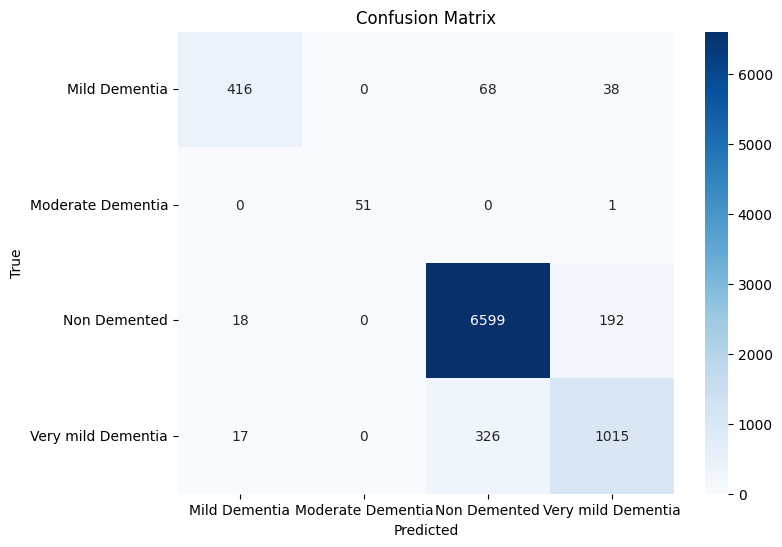

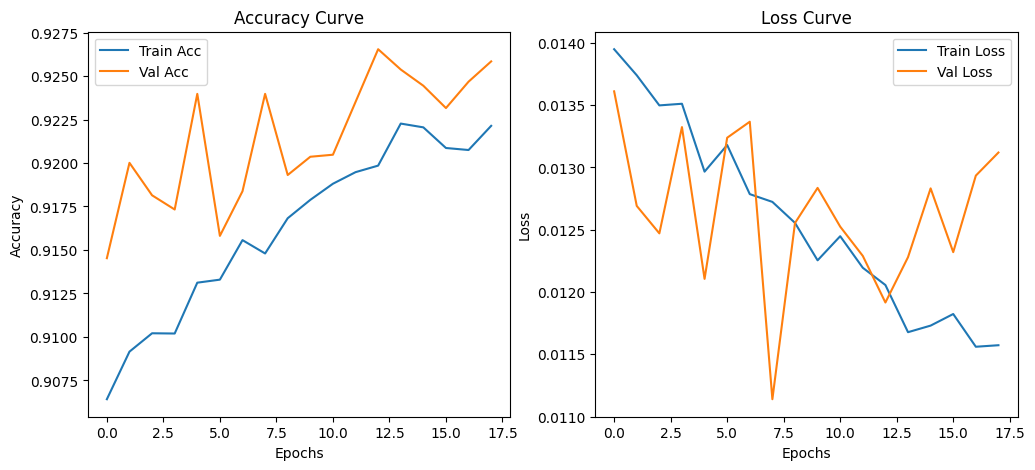

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Load Best Model ---
best_model = tf.keras.models.load_model(BEST_MODEL_SAVE_PATH, custom_objects={'focal_loss': focal_loss_fn()})

# --- Evaluate ---
train_loss, train_acc = best_model.evaluate(train_dataset)
val_loss, val_acc = best_model.evaluate(val_dataset)
test_loss, test_acc = best_model.evaluate(test_dataset)

print("\n--- Final Overall Performance ---")
print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print(f"Training Loss:   {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")
print(f"Test Loss:       {test_loss:.4f}")

# --- Predict and Metrics ---
y_true = np.concatenate([y for _, y in test_dataset], axis=0)
y_pred_probs = best_model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- Per-Class Metrics (Test Set) ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# --- Plot Learning Curves ---
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()
